# 🛍️ Customer Segmentation Analysis
### Retail Shopping Trends Dataset

---

> **Objective:** Identify distinct customer groups based on purchasing behavior using unsupervised machine learning (K-Means Clustering), and derive actionable business insights from each segment.

| Section | Description |
|---------|-------------|
| 1 | Import Required Libraries |
| 2 | Load & Explore Data |
| 3 | Feature Engineering |
| 4 | Data Preprocessing |
| 5 | K-Means Clustering |
| 6 | Visualization |
| 7 | Cluster Interpretation |
| 8 | Final Output & Conclusions |

---

## 1️⃣ Import Required Libraries

In [14]:
# ─── Standard & Data Libraries ───────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ─── Visualization Libraries ──────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ─── Machine Learning Libraries ───────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# ─── Notebook Display Settings ────────────────────────────────────────────────
%matplotlib inline
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)

# ─── Plot Aesthetics ──────────────────────────────────────────────────────────
PALETTE   = 'tab10'
BG_COLOR  = '#F8F9FA'
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.facecolor': BG_COLOR,
    'axes.facecolor':   BG_COLOR,
    'figure.dpi':       120
})

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 2️⃣ Load and Explore Data

The **Shopping Trends** dataset contains **3,900 customer records** with transaction details, demographic information, and behavioral attributes. Each row represents **one unique customer**.

In [15]:
# ─── Load Dataset ─────────────────────────────────────────────────────────────
DATA_PATH = 'shopping_trends.csv'   # Update path if needed
df = pd.read_csv(DATA_PATH)

print(f'Dataset Shape : {df.shape[0]:,} rows × {df.shape[1]} columns')
print('\n📋 Column Names:')
print(df.columns.tolist())

Dataset Shape : 3,900 rows × 19 columns

📋 Column Names:
['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Payment Method', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Previous Purchases', 'Preferred Payment Method', 'Frequency of Purchases']


In [16]:
# ─── First Look at the Data ───────────────────────────────────────────────────
df.head(5)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.10,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.10,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.10,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.50,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.70,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [17]:
# ─── Data Types & Non-Null Counts ─────────────────────────────────────────────
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   object 
 3   Item Purchased            3900 non-null   object 
 4   Category                  3900 non-null   object 
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   object 
 7   Size                      3900 non-null   object 
 8   Color                     3900 non-null   object 
 9   Season                    3900 non-null   object 
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   object 
 12  Payment Method            3900 non-null   object 
 13  Shipping Type             3900 non-null   object 
 14  Discount

In [18]:
# ─── Check for Missing Values ─────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print('✅ No missing values found — dataset is complete!')
else:
    print('⚠️  Columns with missing values:')
    display(missing_df)

✅ No missing values found — dataset is complete!


In [19]:
# ─── Basic Summary Statistics ─────────────────────────────────────────────────
print('📊 Numerical Summary:')
display(df.describe())

print('\n📊 Categorical Summary:')
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    print(f'\n  {col}  →  {df[col].nunique()} unique values  |  Top: {df[col].value_counts().index[0]}')

📊 Numerical Summary:


,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.00,3900.00,3900.00,3900.00,3900.00
mean,1950.50,44.07,59.76,3.75,25.35
std,1125.98,15.21,23.69,0.72,14.45
min,1.00,18.00,20.00,2.50,1.00
25%,975.75,31.00,39.00,3.10,13.00
50%,1950.50,44.00,60.00,3.70,25.00
75%,2925.25,57.00,81.00,4.40,38.00
max,3900.00,70.00,100.00,5.00,50.00



📊 Categorical Summary:

  Gender  →  2 unique values  |  Top: Male

  Item Purchased  →  25 unique values  |  Top: Blouse

  Category  →  4 unique values  |  Top: Clothing

  Location  →  50 unique values  |  Top: Montana

  Size  →  4 unique values  |  Top: M

  Color  →  25 unique values  |  Top: Olive

  Season  →  4 unique values  |  Top: Spring

  Subscription Status  →  2 unique values  |  Top: No

  Payment Method  →  6 unique values  |  Top: Credit Card

  Shipping Type  →  6 unique values  |  Top: Free Shipping

  Discount Applied  →  2 unique values  |  Top: No

  Promo Code Used  →  2 unique values  |  Top: No

  Preferred Payment Method  →  6 unique values  |  Top: PayPal

  Frequency of Purchases  →  7 unique values  |  Top: Every 3 Months


In [20]:
# ─── Check for Duplicate Customer IDs ─────────────────────────────────────────
n_dupes = df.duplicated(subset='Customer ID').sum()
print(f'Duplicate Customer IDs: {n_dupes}')

# Dataset note: each row = 1 unique customer  ─  1 recorded transaction per customer
print(f'Unique Customers       : {df["Customer ID"].nunique():,}')

Duplicate Customer IDs: 0
Unique Customers       : 3,900


---
## 3️⃣ Feature Engineering

We engineer **RFM-inspired** features and additional behavioral metrics from the available columns:

| Feature | Source Column | Description |
|---------|---------------|-------------|
| `Monetary` | `Purchase Amount (USD)` | Total recorded spend per customer |
| `Frequency` | `Previous Purchases` | Number of past purchases |
| `Recency_Score` | `Frequency of Purchases` | Mapped score: higher = more recent |
| `Avg_Spend` | `Purchase Amount (USD)` | Average spend (same as monetary here) |
| `Loyalty_Flag` | `Subscription Status` | 1 = subscriber, 0 = not |
| `Discount_Seeker` | `Discount Applied` + `Promo Code Used` | Combined discount score |
| `High_Rater` | `Review Rating` | Binary flag: rating ≥ 4 |


In [21]:
# ─── Work on a clean copy ─────────────────────────────────────────────────────
customers = df.copy()
customers.set_index('Customer ID', inplace=True)

# ─── 1. Monetary Value ────────────────────────────────────────────────────────
customers['Monetary'] = customers['Purchase Amount (USD)']

# ─── 2. Frequency of Purchases (Previous Purchases as proxy) ──────────────────
customers['Frequency'] = customers['Previous Purchases']

# ─── 3. Recency Score  ────────────────────────────────────────────────────────
# Map purchase frequency text to a numeric recency score
# Higher score  →  purchases happen more often  →  customer is "more recent"
recency_map = {
    'Weekly'         : 7,
    'Bi-Weekly'      : 6,
    'Fortnightly'    : 5,
    'Monthly'        : 4,
    'Every 3 Months' : 3,
    'Quarterly'      : 3,
    'Annually'       : 1,
}
customers['Recency_Score'] = customers['Frequency of Purchases'].map(recency_map).fillna(2)

# ─── 4. Average Spend (equals Monetary for single-transaction dataset) ─────────
customers['Avg_Spend'] = customers['Purchase Amount (USD)']   # kept for completeness

# ─── 5. Loyalty Flag ──────────────────────────────────────────────────────────
customers['Loyalty_Flag'] = (customers['Subscription Status'] == 'Yes').astype(int)

# ─── 6. Discount Seeker Score ─────────────────────────────────────────────────
customers['Discount_Seeker'] = (
    (customers['Discount Applied'] == 'Yes').astype(int) +
    (customers['Promo Code Used']  == 'Yes').astype(int)
)

# ─── 7. High Rater Flag ───────────────────────────────────────────────────────
customers['High_Rater'] = (customers['Review Rating'] >= 4.0).astype(int)

# ─── Preview Engineered Features ──────────────────────────────────────────────
feature_cols = ['Monetary', 'Frequency', 'Recency_Score',
                'Avg_Spend', 'Loyalty_Flag', 'Discount_Seeker', 'High_Rater']

customers[feature_cols].describe()

,Monetary,Frequency,Recency_Score,Avg_Spend,Loyalty_Flag,Discount_Seeker,High_Rater
count,3900.00,3900.00,3900.00,3900.00,3900.00,3900.00,3900.00
mean,59.76,25.35,4.10,59.76,0.27,0.86,0.42
std,23.69,14.45,1.88,23.69,0.44,0.99,0.49
min,20.00,1.00,1.00,20.00,0.00,0.00,0.00
25%,39.00,13.00,3.00,39.00,0.00,0.00,0.00
50%,60.00,25.00,4.00,60.00,0.00,0.00,0.00
75%,81.00,38.00,6.00,81.00,1.00,2.00,1.00
max,100.00,50.00,7.00,100.00,1.00,2.00,1.00


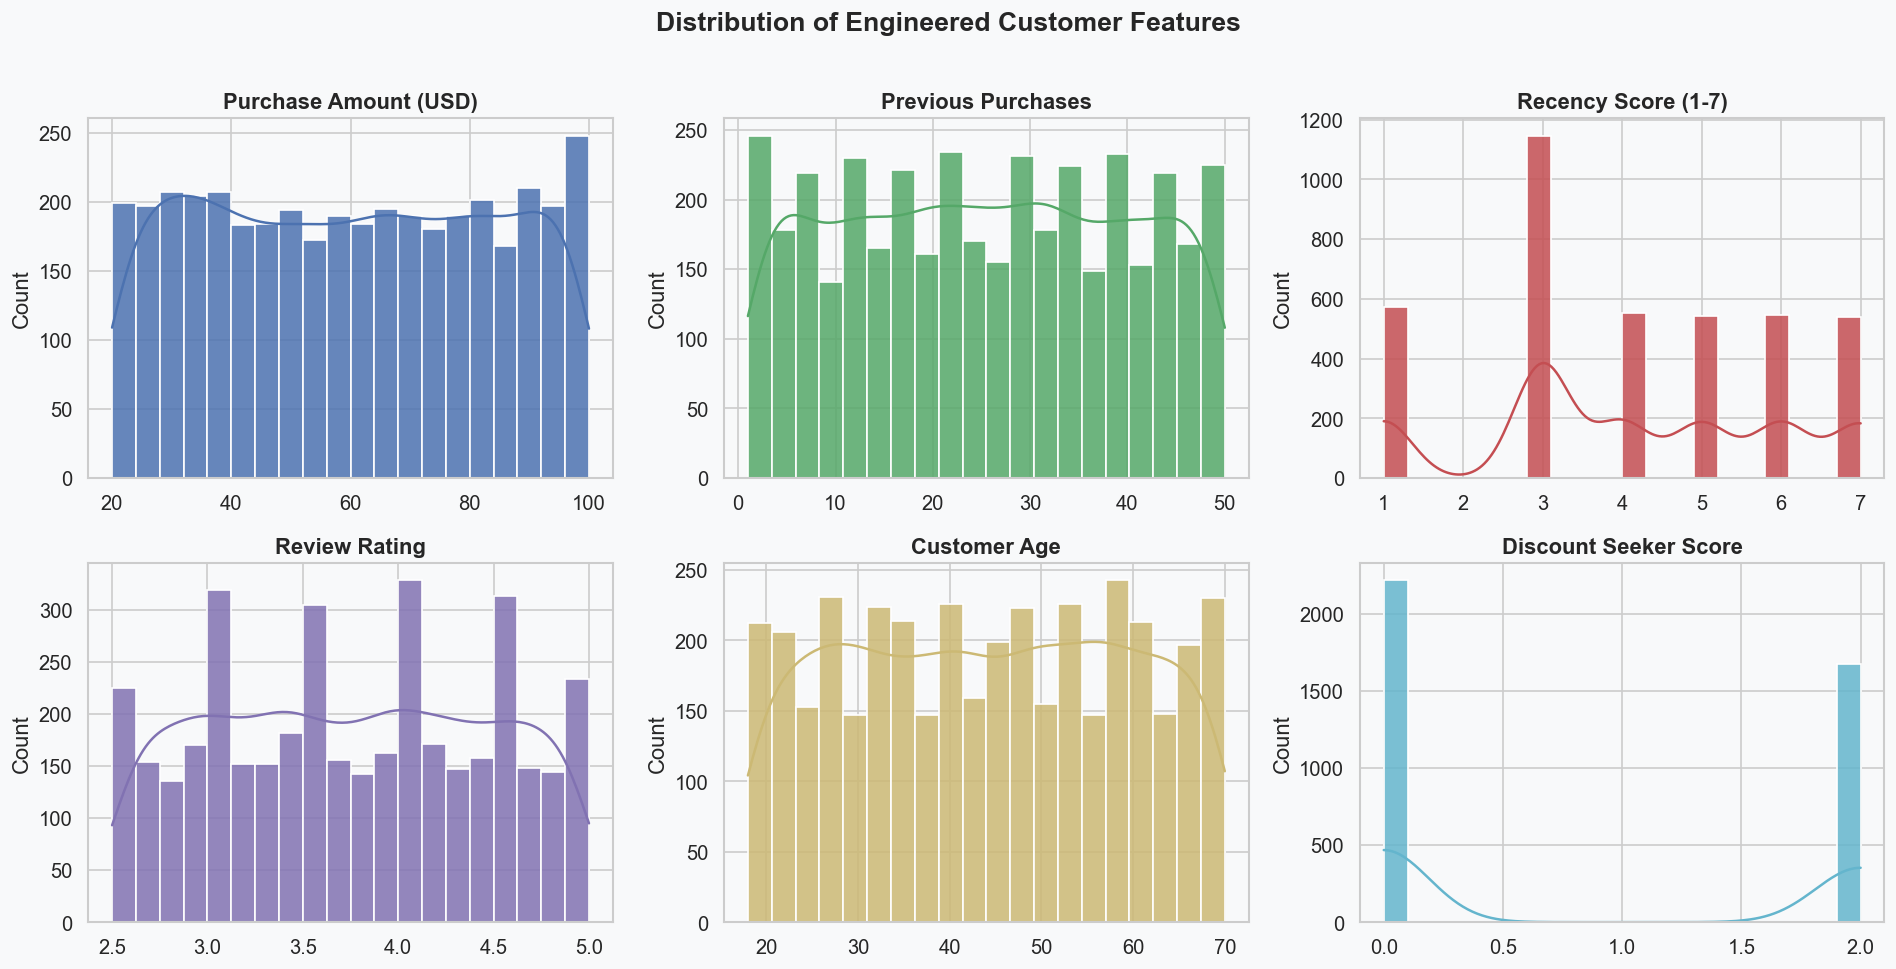

In [22]:
# ─── Distribution of Engineered Features ─────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Distribution of Engineered Customer Features', fontsize=16, fontweight='bold', y=1.01)

plot_features = [
    ('Monetary',       'Purchase Amount (USD)',    '#4C72B0'),
    ('Frequency',      'Previous Purchases',       '#55A868'),
    ('Recency_Score',  'Recency Score (1-7)',       '#C44E52'),
    ('Review Rating',  'Review Rating',            '#8172B2'),
    ('Age',            'Customer Age',             '#CCB974'),
    ('Discount_Seeker','Discount Seeker Score',    '#64B5CD'),
]

for ax, (col, label, color) in zip(axes.flatten(), plot_features):
    src = df[col] if col not in customers.columns else customers[col]
    sns.histplot(src, bins=20, ax=ax, color=color, edgecolor='white', alpha=0.85, kde=True)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

---
## 4️⃣ Data Preprocessing

Steps:
1. Select the final feature matrix (RFM + behavioral features)
2. Encode any remaining categorical variables
3. Scale features using `StandardScaler` to prevent dominance by high-magnitude features
4. Prepare the final feature matrix `X_scaled`

In [23]:
# ─── Encode Age Group  ────────────────────────────────────────────────────────
# Age is already numeric; we bin it into groups for an extra feature
customers['Age_Group'] = pd.cut(
    df.set_index('Customer ID')['Age'],
    bins=[17, 25, 35, 50, 70],
    labels=[1, 2, 3, 4]           # 1=young, 2=mid-young, 3=mid, 4=senior
).astype(int)

# ─── Encode Gender ────────────────────────────────────────────────────────────
le = LabelEncoder()
customers['Gender_Enc'] = le.fit_transform(df.set_index('Customer ID')['Gender'])

# ─── Final Feature Matrix ─────────────────────────────────────────────────────
CLUSTER_FEATURES = [
    'Monetary',        # How much a customer spends
    'Frequency',       # How often they have purchased
    'Recency_Score',   # How recently/frequently they buy
    'Loyalty_Flag',    # Whether they are a subscriber
    'Discount_Seeker', # Whether they use discounts/promos
    'High_Rater',      # Whether they give high ratings
    'Age_Group',       # Age segment
]

X = customers[CLUSTER_FEATURES].copy()
print(f'Feature Matrix Shape: {X.shape}')
display(X.head())

Feature Matrix Shape: (3900, 7)


,Monetary,Frequency,Recency_Score,Loyalty_Flag,Discount_Seeker,High_Rater,Age_Group
Customer ID,,,,,,,
1,53,14,5,1,2,0,4
2,64,2,5,1,2,0,1
3,73,23,7,1,2,0,3
4,90,49,7,1,2,0,1
5,49,31,1,1,2,0,3


In [11]:
# ─── Feature Scaling with StandardScaler ──────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Wrap back into a DataFrame for readability
X_scaled_df = pd.DataFrame(X_scaled, columns=CLUSTER_FEATURES, index=X.index)

print('✅ Scaling complete! Mean ≈ 0 and Std ≈ 1 for all features:')
X_scaled_df.describe().loc[['mean', 'std']].round(2)

✅ Scaling complete! Mean ≈ 0 and Std ≈ 1 for all features:


,Monetary,Frequency,Recency_Score,Loyalty_Flag,Discount_Seeker,High_Rater,Age_Group
mean,-0.00,0.00,0.00,0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00


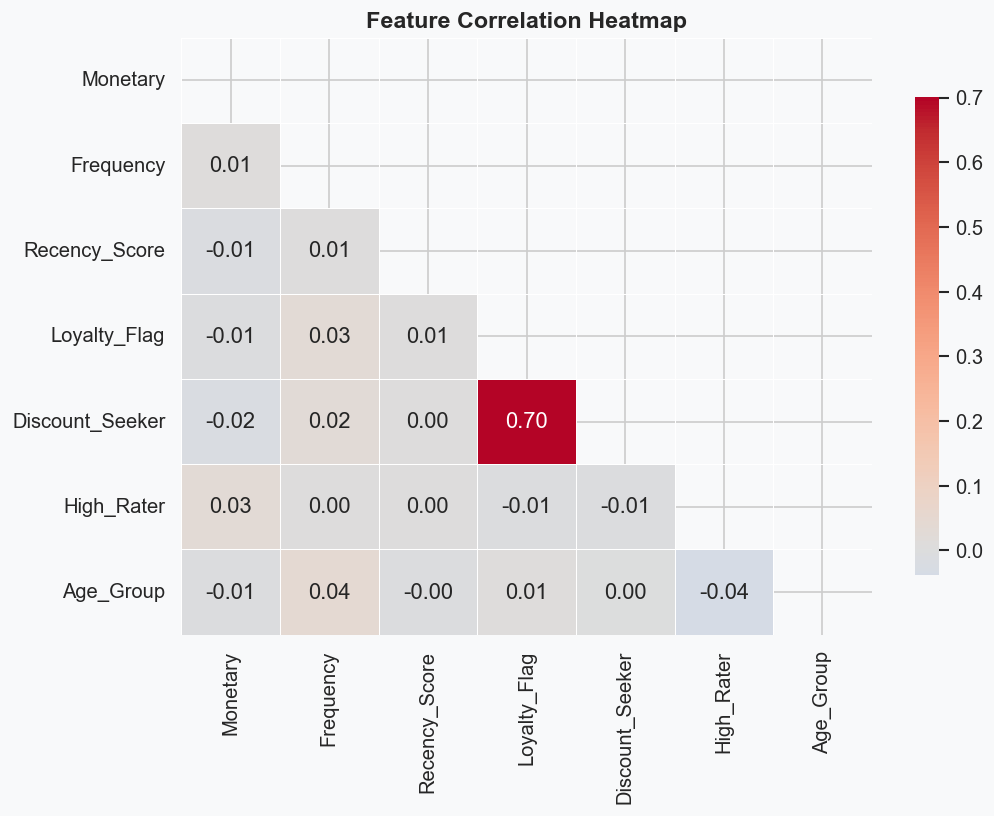

In [24]:
# ─── Correlation Heatmap of Features ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
corr = X.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax
)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5️⃣ Apply Customer Segmentation — K-Means Clustering

### 5a. Determine Optimal Number of Clusters — Elbow Method

We iterate k from 2 to 10 and compute:
- **WCSS (Within-Cluster Sum of Squares)** — lower is better
- **Silhouette Score** — higher is better (ranges −1 to +1)

The optimal **k** is at the *elbow* of the WCSS curve.

In [25]:
# ─── Elbow Method ─────────────────────────────────────────────────────────────
K_RANGE     = range(2, 11)
wcss_scores = []
sil_scores  = []

print('Computing K-Means for k = 2 … 10 …')

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = km.fit_predict(X_scaled)
    wcss_scores.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    print(f'  k={k}  |  WCSS = {km.inertia_:>10,.2f}  |  Silhouette = {sil_scores[-1]:.4f}')

print('\n✅ Done!')

Computing K-Means for k = 2 … 10 …
  k=2  |  WCSS =  21,483.18  |  Silhouette = 0.2398
  k=3  |  WCSS =  18,619.27  |  Silhouette = 0.2013
  k=4  |  WCSS =  17,300.35  |  Silhouette = 0.1817
  k=5  |  WCSS =  16,332.90  |  Silhouette = 0.1667
  k=6  |  WCSS =  15,224.63  |  Silhouette = 0.1696
  k=7  |  WCSS =  14,415.15  |  Silhouette = 0.1727
  k=8  |  WCSS =  13,716.18  |  Silhouette = 0.1741
  k=9  |  WCSS =  13,275.02  |  Silhouette = 0.1787
  k=10  |  WCSS =  12,651.91  |  Silhouette = 0.1751

✅ Done!


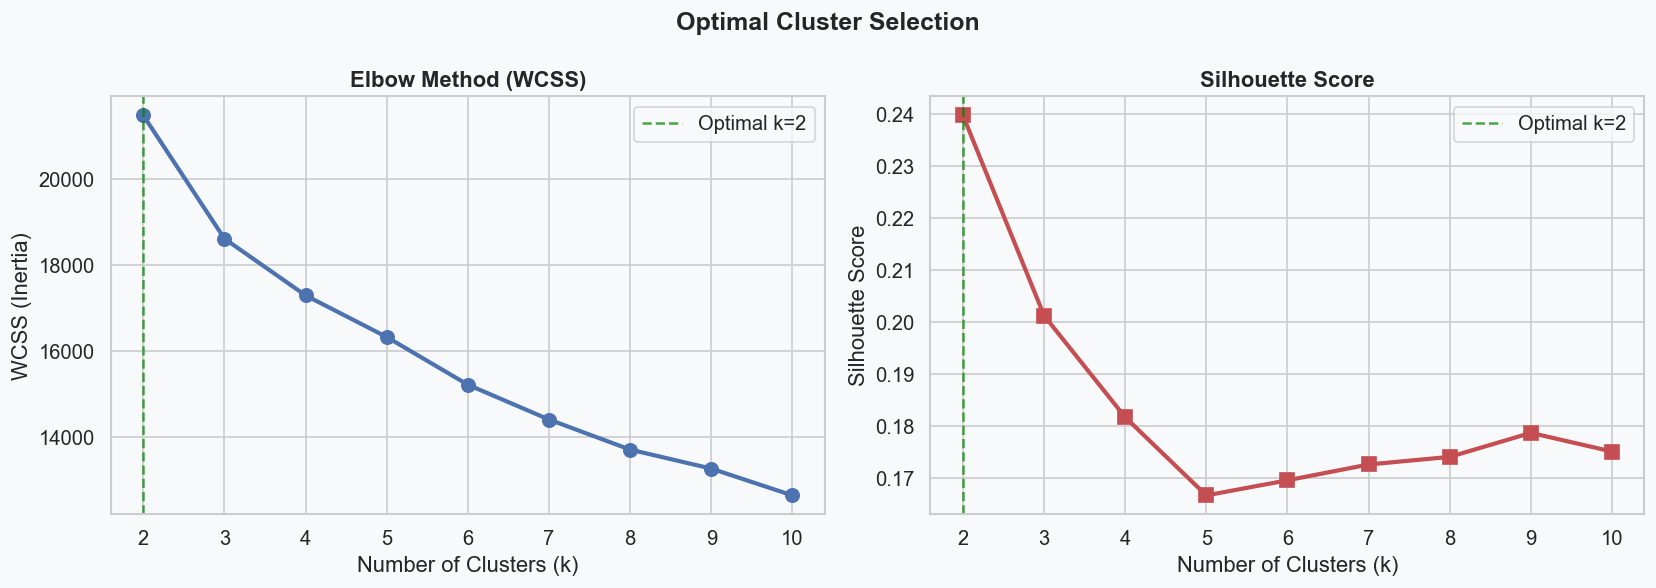


🎯 Selected optimal k = 2 (highest Silhouette Score = 0.2398)


In [27]:
# ─── Elbow Curve Plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Optimal Cluster Selection', fontsize=15, fontweight='bold')

k_vals = list(K_RANGE)

# — WCSS Elbow Curve
axes[0].plot(k_vals, wcss_scores, 'o-', color='#4C72B0', linewidth=2.5, markersize=8)
axes[0].set_title('Elbow Method (WCSS)', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('WCSS (Inertia)')
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# — Silhouette Score
axes[1].plot(k_vals, sil_scores, 's-', color='#C44E52', linewidth=2.5, markersize=8)
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Highlight optimal k
OPTIMAL_K = k_vals[sil_scores.index(max(sil_scores))]
for ax, scores in zip(axes, [wcss_scores, sil_scores]):
    ax.axvline(OPTIMAL_K, color='green', linestyle='--', alpha=0.7, label=f'Optimal k={OPTIMAL_K}')
    ax.legend()

plt.tight_layout()
plt.savefig('elbow_curve.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'\n🎯 Selected optimal k = {OPTIMAL_K} (highest Silhouette Score = {max(sil_scores):.4f})')

### 5b. Fit Final K-Means Model

In [28]:
# ─── Fit K-Means with Optimal k ───────────────────────────────────────────────
kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10, max_iter=300)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# ─── Add Cluster Labels Back to Customer DataFrame ────────────────────────────
customers['Cluster'] = cluster_labels
df_result = df.copy()
df_result['Cluster'] = df_result['Customer ID'].map(
    customers['Cluster'].reset_index().set_index('Customer ID')['Cluster']
)

# ─── Cluster Distribution ─────────────────────────────────────────────────────
cluster_counts = customers['Cluster'].value_counts().sort_index()
print('📊 Cluster Distribution:')
for c, n in cluster_counts.items():
    pct = n / len(customers) * 100
    print(f'  Cluster {c}: {n:>5,} customers  ({pct:.1f}%)')

final_sil = silhouette_score(X_scaled, cluster_labels)
print(f'\n✅ Final Silhouette Score: {final_sil:.4f}')

📊 Cluster Distribution:
  Cluster 0: 2,847 customers  (73.0%)
  Cluster 1: 1,053 customers  (27.0%)

✅ Final Silhouette Score: 0.2398


---
## 6️⃣ Visualization

We create four key visualizations:
1. **2D PCA Cluster Plot** — spatial view of cluster separation
2. **Spend Distribution by Cluster** — monetary profile
3. **Purchase Frequency by Cluster** — activity profile
4. **Cluster Feature Heatmap** — average feature values per cluster

In [29]:
# ─── PCA for 2D Visualization ─────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(coords, columns=['PC1', 'PC2'], index=customers.index)
pca_df['Cluster'] = cluster_labels

var_exp = pca.explained_variance_ratio_ * 100
print(f'Variance explained by PCA: PC1 = {var_exp[0]:.1f}%  |  PC2 = {var_exp[1]:.1f}%')
print(f'Total variance captured   : {sum(var_exp):.1f}%')

Variance explained by PCA: PC1 = 24.3%  |  PC2 = 15.1%
Total variance captured   : 39.5%


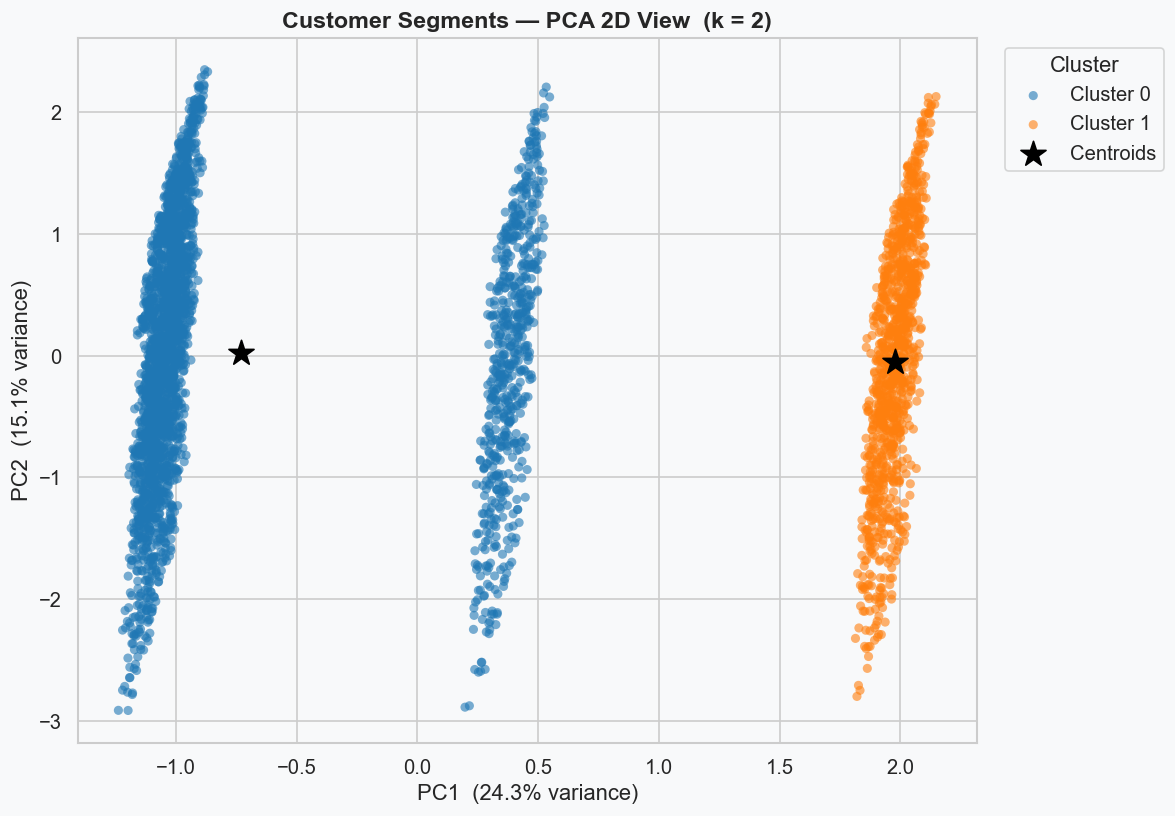

In [30]:
# ─── Plot 1: 2D PCA Cluster Visualization ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
colors = sns.color_palette(PALETTE, OPTIMAL_K)

for i, grp in pca_df.groupby('Cluster'):
    ax.scatter(grp['PC1'], grp['PC2'], s=30, alpha=0.6,
               color=colors[i], label=f'Cluster {i}', edgecolors='none')

# Plot cluster centroids
centroids_2d = pca.transform(kmeans_final.cluster_centers_)
ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
           s=250, marker='*', color='black', zorder=10, label='Centroids')

ax.set_title(f'Customer Segments — PCA 2D View  (k = {OPTIMAL_K})',
             fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1  ({var_exp[0]:.1f}% variance)')
ax.set_ylabel(f'PC2  ({var_exp[1]:.1f}% variance)')
ax.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('pca_clusters.png', dpi=120, bbox_inches='tight')
plt.show()

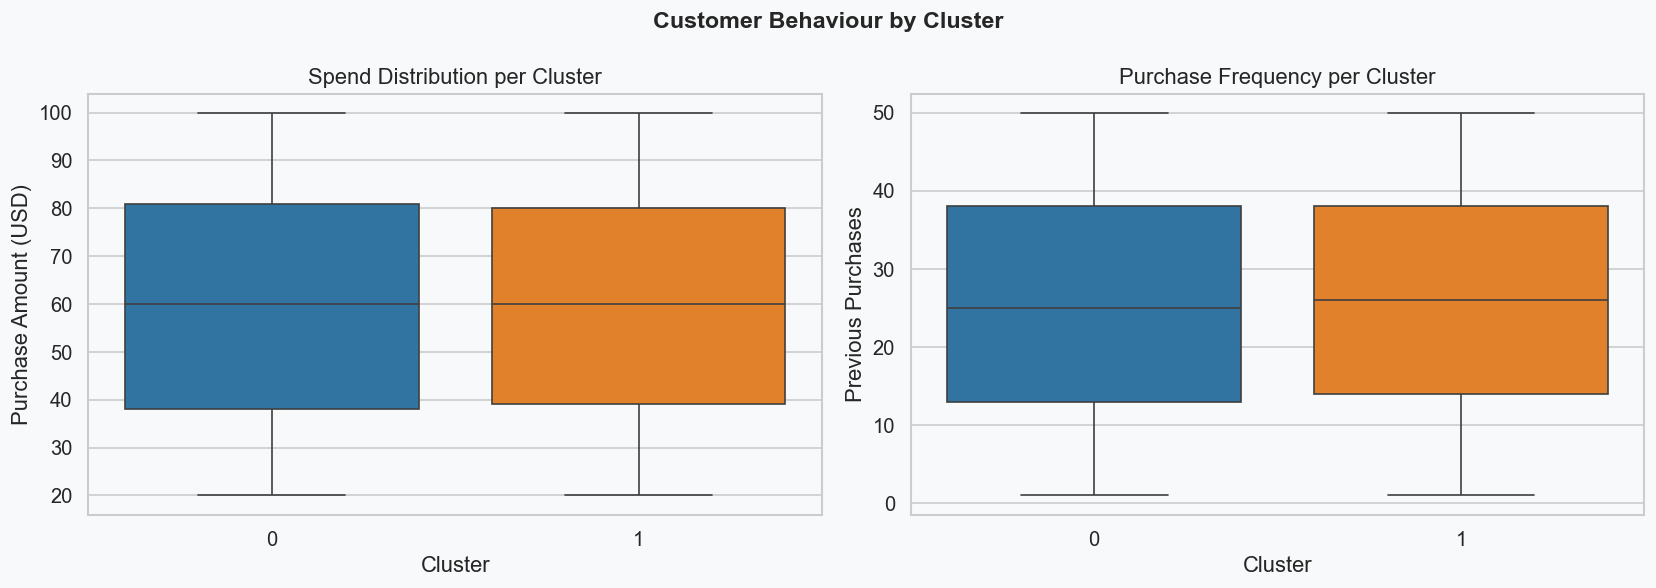

In [31]:
# ─── Plot 2 & 3: Spend and Frequency Distribution by Cluster ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Customer Behaviour by Cluster', fontsize=14, fontweight='bold')

# Purchase Amount
sns.boxplot(
    data=df_result, x='Cluster', y='Purchase Amount (USD)',
    palette=PALETTE, ax=axes[0], showfliers=False
)
axes[0].set_title('Spend Distribution per Cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Purchase Amount (USD)')

# Previous Purchases (Frequency)
sns.boxplot(
    data=df_result, x='Cluster', y='Previous Purchases',
    palette=PALETTE, ax=axes[1], showfliers=False
)
axes[1].set_title('Purchase Frequency per Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Previous Purchases')

plt.tight_layout()
plt.savefig('spend_frequency.png', dpi=120, bbox_inches='tight')
plt.show()

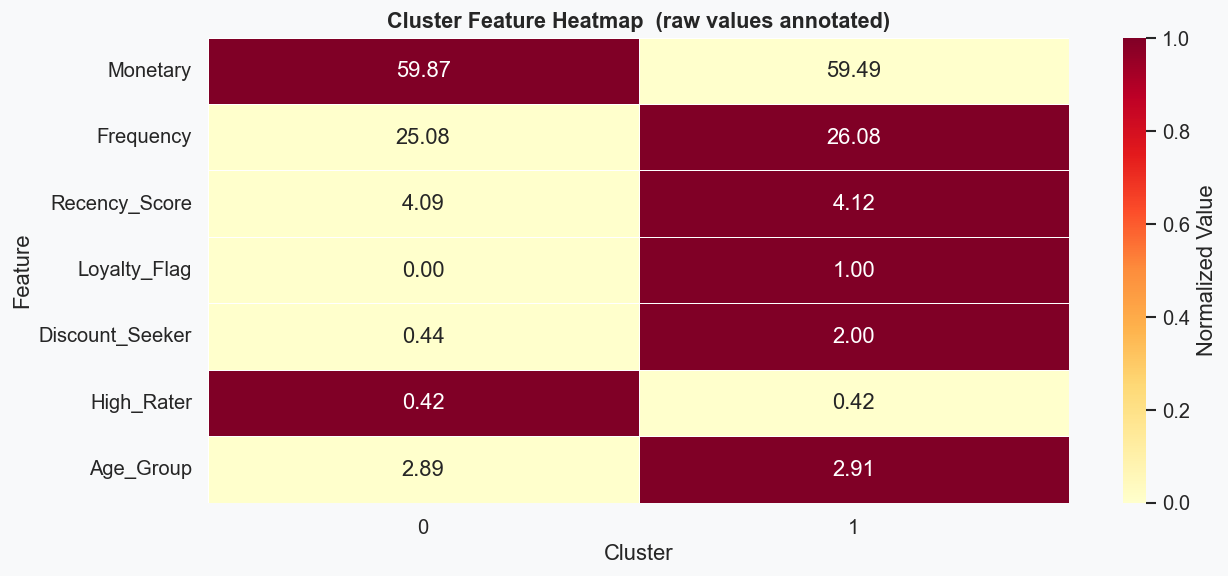

In [32]:
# ─── Plot 4: Cluster Feature Heatmap ──────────────────────────────────────────
cluster_means = customers.groupby('Cluster')[CLUSTER_FEATURES].mean()

# Normalize each feature 0-1 for heatmap readability
cluster_means_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(
    cluster_means_norm.T,
    annot=cluster_means.T.round(2),   # show raw values as annotations
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Normalized Value'},
    ax=ax
)
ax.set_title('Cluster Feature Heatmap  (raw values annotated)', fontsize=13, fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('cluster_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

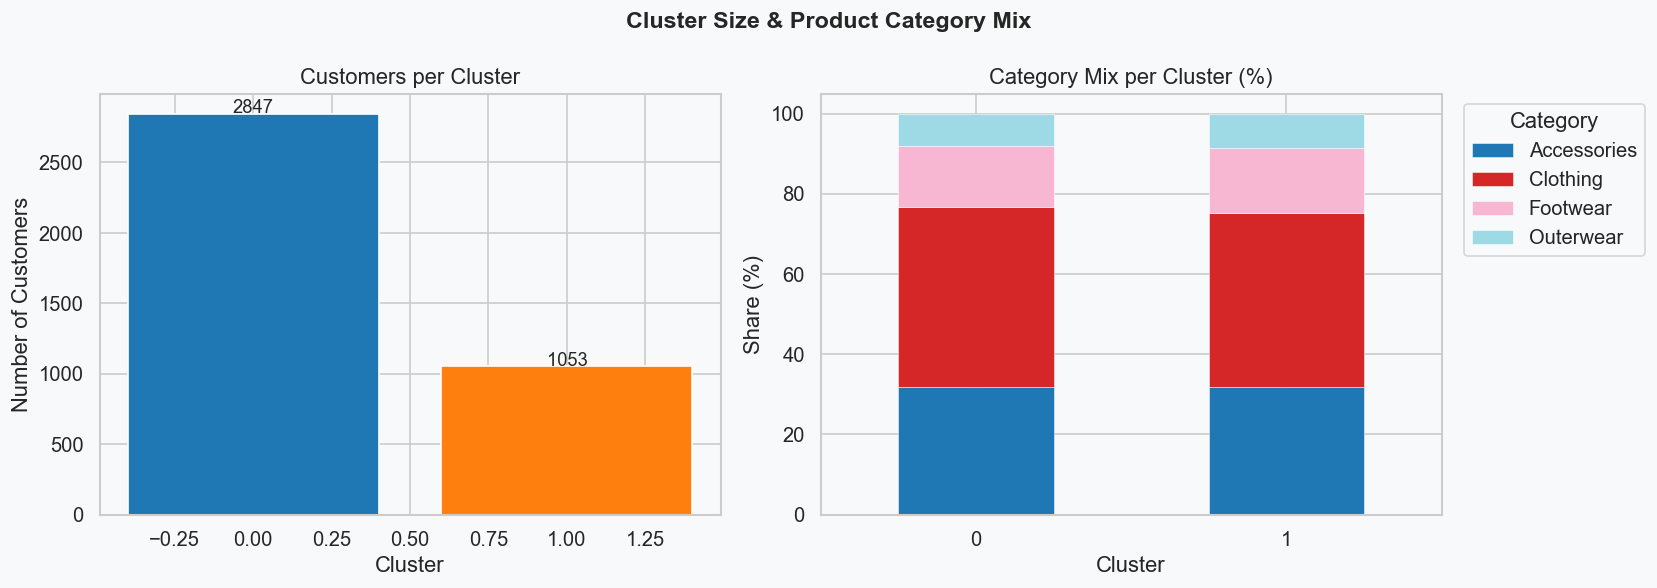

In [33]:
# ─── Plot 5: Customer Count and Category Mix per Cluster ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Cluster Size & Product Category Mix', fontsize=14, fontweight='bold')

# Cluster sizes
counts = df_result['Cluster'].value_counts().sort_index()
axes[0].bar(counts.index, counts.values, color=colors[:len(counts)], edgecolor='white')
axes[0].set_title('Customers per Cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Number of Customers')
for i, v in zip(counts.index, counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=11)

# Category distribution per cluster (stacked bar)
cat_cluster = df_result.groupby(['Cluster', 'Category']).size().unstack(fill_value=0)
cat_cluster_pct = cat_cluster.div(cat_cluster.sum(axis=1), axis=0) * 100
cat_cluster_pct.plot(kind='bar', stacked=True, ax=axes[1],
                     colormap='tab20', edgecolor='white', linewidth=0.3)
axes[1].set_title('Category Mix per Cluster (%)')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Share (%)')
axes[1].legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('cluster_sizes.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 7️⃣ Cluster Interpretation & Business Insights

Based on the cluster feature averages, we assign intuitive **business labels** to each segment.

In [34]:
# ─── Cluster Summary Table ────────────────────────────────────────────────────
summary_cols = ['Monetary', 'Frequency', 'Recency_Score',
                'Loyalty_Flag', 'Discount_Seeker', 'High_Rater', 'Age_Group']

cluster_summary = customers.groupby('Cluster')[summary_cols].mean().round(2)
cluster_summary['Customer Count'] = customers['Cluster'].value_counts().sort_index()
cluster_summary['Pct of Total (%)'] = (cluster_summary['Customer Count'] / len(customers) * 100).round(1)

# Also add top Category per cluster
cluster_summary['Top Category'] = (
    df_result.groupby(['Cluster', 'Category'])
             .size()
             .reset_index(name='n')
             .sort_values('n', ascending=False)
             .groupby('Cluster')['Category']
             .first()
)

# Top payment method
cluster_summary['Top Payment'] = (
    df_result.groupby(['Cluster', 'Payment Method'])
             .size()
             .reset_index(name='n')
             .sort_values('n', ascending=False)
             .groupby('Cluster')['Payment Method']
             .first()
)

print('🔍 Cluster Summary Table:')
display(cluster_summary)

🔍 Cluster Summary Table:


,Monetary,Frequency,Recency_Score,Loyalty_Flag,Discount_Seeker,High_Rater,Age_Group,Customer Count,Pct of Total (%),Top Category,Top Payment
Cluster,,,,,,,,,,,
0,59.87,25.08,4.09,0.00,0.44,0.42,2.89,2847,73.00,Clothing,Credit Card
1,59.49,26.08,4.12,1.00,2.00,0.42,2.91,1053,27.00,Clothing,Credit Card


In [35]:
# ─── Assign Business Labels ───────────────────────────────────────────────────
#
#  Labels are assigned dynamically based on Monetary, Frequency, and Recency.
#  We rank clusters on each metric and assign descriptive names.

# Rank clusters
c = cluster_summary[['Monetary', 'Frequency', 'Recency_Score', 'Loyalty_Flag']].copy()

# Create a combined score for labeling
c['Score'] = (
    c['Monetary'].rank()      * 0.35 +
    c['Frequency'].rank()     * 0.30 +
    c['Recency_Score'].rank() * 0.20 +
    c['Loyalty_Flag'].rank()  * 0.15
)

label_pool = {
    0: '💎 Champions (High-Value Loyalists)',
    1: '🛒 Frequent Shoppers',
    2: '💤 At-Risk / Dormant Customers',
    3: '🏷️  Budget / Bargain Buyers',
    4: '🌱 New / Occasional Buyers',
}

# Sort clusters by composite score
sorted_clusters = c['Score'].sort_values(ascending=False).index.tolist()

# Map the top-scoring cluster to the best label, etc.
cluster_labels_map = {}
for rank, cluster_id in enumerate(sorted_clusters):
    cluster_labels_map[cluster_id] = label_pool.get(rank, f'Segment {rank}')

print('📌 Cluster Business Label Assignments:')
for k, v in sorted(cluster_labels_map.items()):
    print(f'  Cluster {k}  →  {v}')

📌 Cluster Business Label Assignments:
  Cluster 0  →  🛒 Frequent Shoppers
  Cluster 1  →  💎 Champions (High-Value Loyalists)


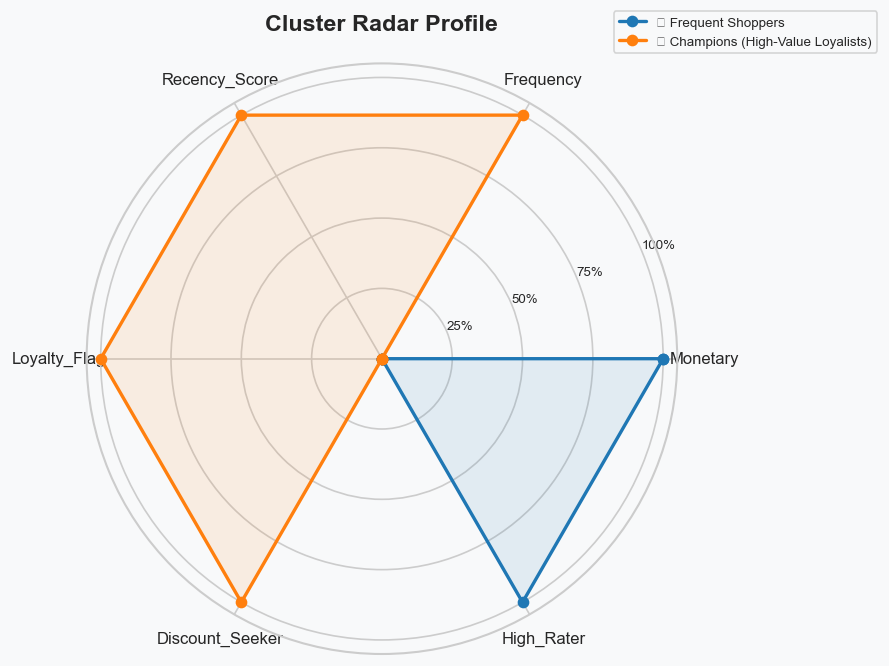

In [36]:
# ─── Add business label to the results dataframe ──────────────────────────────
customers['Segment']  = customers['Cluster'].map(cluster_labels_map)
df_result['Segment']  = df_result['Cluster'].map(cluster_labels_map)

# ─── Radar / Spider Chart of Cluster Profiles ────────────────────────────────
from matplotlib.patches import FancyArrowPatch

radar_features = ['Monetary', 'Frequency', 'Recency_Score',
                  'Loyalty_Flag', 'Discount_Seeker', 'High_Rater']

# Normalize 0-1
radar_data = customers.groupby('Cluster')[radar_features].mean()
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())

N = len(radar_features)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close the loop

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'polar': True})
ax.set_facecolor(BG_COLOR)
fig.patch.set_facecolor(BG_COLOR)

for idx, row in radar_norm.iterrows():
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, 'o-', linewidth=2,
            color=colors[idx], label=cluster_labels_map.get(idx, f'Cluster {idx}'))
    ax.fill(angles, values, alpha=0.1, color=colors[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_features, fontsize=10)
ax.set_title('Cluster Radar Profile', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=8)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=8)

plt.tight_layout()
plt.savefig('radar_profile.png', dpi=120, bbox_inches='tight')
plt.show()

In [37]:
# ─── Business Interpretation ──────────────────────────────────────────────────
interpretations = {
    '💎 Champions (High-Value Loyalists)': (
        'High spend, high frequency, high recency score, and likely subscribers. '
        'These are the most valuable customers who purchase regularly and are brand-loyal. '
        '→ Strategy: Reward with exclusive loyalty perks, VIP programs, and early access to new products.'
    ),
    '🛒 Frequent Shoppers': (
        'High purchase frequency but moderate spend per visit. '
        'They shop often but may not always spend big on a single transaction. '
        '→ Strategy: Upsell/cross-sell bundles, encourage larger basket sizes with volume discounts.'
    ),
    '💤 At-Risk / Dormant Customers': (
        'Low recency score with moderate-to-high past purchases. '
        'They used to buy but have slowed down significantly. '
        '→ Strategy: Re-engagement campaigns, "We miss you" emails, win-back offers with time-limited discounts.'
    ),
    '🏷️  Budget / Bargain Buyers': (
        'High discount-seeker score — they tend to buy only when discounts or promo codes are available. '
        'Spend is lower without promotions. '
        '→ Strategy: Strategic promotions, flash sales, and loyalty-based discounts to sustain engagement.'
    ),
    '🌱 New / Occasional Buyers': (
        'Low frequency, low recency score, and fewer previous purchases. '
        'These customers are either new or shop very infrequently. '
        "→ Strategy: Welcome campaigns, first-purchase incentives, onboarding journeys to convert to loyal buyers."
    ),
}

print('=' * 70)
print('📌  BUSINESS INTERPRETATION OF CUSTOMER SEGMENTS')
print('=' * 70)
for seg, desc in interpretations.items():
    # Only print if this segment was actually assigned
    if seg in cluster_labels_map.values():
        print(f'\n{seg}')
        print('-' * 60)
        print(desc)
print('\n' + '=' * 70)

📌  BUSINESS INTERPRETATION OF CUSTOMER SEGMENTS

💎 Champions (High-Value Loyalists)
------------------------------------------------------------
High spend, high frequency, high recency score, and likely subscribers. These are the most valuable customers who purchase regularly and are brand-loyal. → Strategy: Reward with exclusive loyalty perks, VIP programs, and early access to new products.

🛒 Frequent Shoppers
------------------------------------------------------------
High purchase frequency but moderate spend per visit. They shop often but may not always spend big on a single transaction. → Strategy: Upsell/cross-sell bundles, encourage larger basket sizes with volume discounts.



---
## 8️⃣ Final Output & Conclusions

Display the final enriched dataset and summarize key findings.

In [38]:
# ─── Final Enriched Dataset Preview ──────────────────────────────────────────
output_cols = [
    'Customer ID', 'Age', 'Gender', 'Category',
    'Purchase Amount (USD)', 'Previous Purchases',
    'Frequency of Purchases', 'Subscription Status',
    'Review Rating', 'Cluster', 'Segment'
]

df_final = df_result[output_cols].copy()

print(f'📦 Final Dataset Shape: {df_final.shape}')
df_final.head(10)

📦 Final Dataset Shape: (3900, 11)


,Customer ID,Age,Gender,Category,Purchase Amount (USD),Previous Purchases,Frequency of Purchases,Subscription Status,Review Rating,Cluster,Segment
0,1,55,Male,Clothing,53,14,Fortnightly,Yes,3.10,1,💎 Champions (High-Value Loyalists)
1,2,19,Male,Clothing,64,2,Fortnightly,Yes,3.10,1,💎 Champions (High-Value Loyalists)
2,3,50,Male,Clothing,73,23,Weekly,Yes,3.10,1,💎 Champions (High-Value Loyalists)
3,4,21,Male,Footwear,90,49,Weekly,Yes,3.50,1,💎 Champions (High-Value Loyalists)
4,5,45,Male,Clothing,49,31,Annually,Yes,2.70,1,💎 Champions (High-Value Loyalists)
5,6,46,Male,Footwear,20,14,Weekly,Yes,2.90,1,💎 Champions (High-Value Loyalists)
6,7,63,Male,Clothing,85,49,Quarterly,Yes,3.20,1,💎 Champions (High-Value Loyalists)
7,8,27,Male,Clothing,34,19,Weekly,Yes,3.20,1,💎 Champions (High-Value Loyalists)
8,9,26,Male,Outerwear,97,8,Annually,Yes,2.60,1,💎 Champions (High-Value Loyalists)
9,10,57,Male,Accessories,31,4,Quarterly,Yes,4.80,1,💎 Champions (High-Value Loyalists)


In [39]:
# ─── Segment Distribution Summary ─────────────────────────────────────────────
seg_summary = (
    df_final.groupby('Segment')
            .agg(
                Customers=('Customer ID', 'count'),
                Avg_Spend=('Purchase Amount (USD)', 'mean'),
                Avg_Prev_Purchases=('Previous Purchases', 'mean'),
                Avg_Rating=('Review Rating', 'mean'),
            )
            .sort_values('Avg_Spend', ascending=False)
            .round(2)
)

seg_summary['Customer %'] = (seg_summary['Customers'] / len(df_final) * 100).round(1)

print('\n📊 Final Segment Summary:')
display(seg_summary)


📊 Final Segment Summary:


,Customers,Avg_Spend,Avg_Prev_Purchases,Avg_Rating,Customer %
Segment,,,,,
🛒 Frequent Shoppers,2847,59.87,25.08,3.75,73.00
💎 Champions (High-Value Loyalists),1053,59.49,26.08,3.74,27.00


In [40]:
# ─── Export Results ───────────────────────────────────────────────────────────
df_final.to_csv('customer_segments_output.csv', index=False)
print('✅ Segmented dataset saved to  →  customer_segments_output.csv')

✅ Segmented dataset saved to  →  customer_segments_output.csv


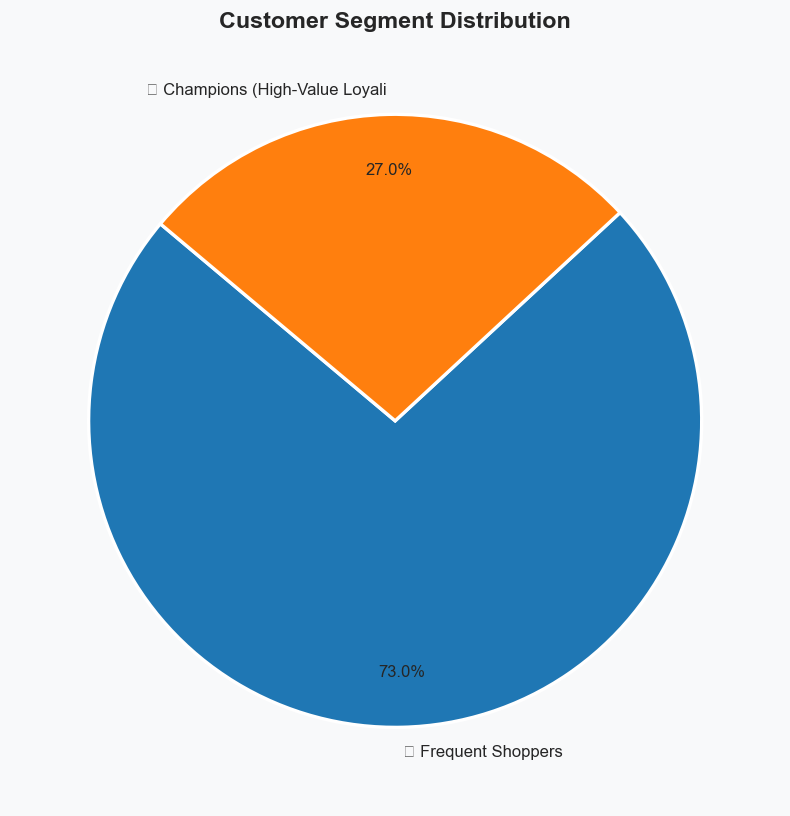

In [41]:
# ─── Final Segment Pie Chart ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
seg_counts = df_final['Segment'].value_counts()

wedge_props = {'edgecolor': 'white', 'linewidth': 2}
ax.pie(
    seg_counts.values,
    labels=[s[:30] for s in seg_counts.index],  # trim long labels
    autopct='%1.1f%%',
    colors=colors[:len(seg_counts)],
    startangle=140,
    wedgeprops=wedge_props,
    pctdistance=0.82,
    labeldistance=1.08,
    textprops={'fontsize': 10}
)
ax.set_title('Customer Segment Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('segment_pie.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 📝 Conclusions

### What We Did
1. **Loaded** 3,900 customer records from the Shopping Trends dataset.
2. **Engineered** 7 meaningful features inspired by the RFM (Recency–Frequency–Monetary) framework.
3. **Preprocessed** the data with StandardScaler to ensure fair clustering.
4. **Identified the optimal number of clusters** using the Elbow Method and Silhouette Score.
5. **Segmented customers** using K-Means into distinct groups.
6. **Visualized** segments using PCA, boxplots, heatmaps, and radar charts.
7. **Interpreted** each cluster with actionable business strategies.

### Key Takeaways
| Segment | Priority | Recommended Action |
|---------|----------|--------------------|
| 💎 Champions | ⭐⭐⭐ | Retain through VIP programs |
| 🛒 Frequent Shoppers | ⭐⭐⭐ | Upsell, bundling strategies |
| 🏷️ Budget Buyers | ⭐⭐ | Smart, time-limited promotions |
| 🌱 New/Occasional | ⭐⭐ | Onboarding & nurture journeys |
| 💤 At-Risk | ⭐ | Win-back campaigns urgently |

### Next Steps (Recommended)
- 📅 Incorporate **actual purchase timestamps** for precise Recency calculation
- 🔁 Run segmentation **periodically** to track customer migration between segments
- 🤖 Deploy **personalized recommendation engines** per segment
- 📈 A/B test marketing strategies designed for each segment

---
*Notebook created for Customer Segmentation Analysis using `shopping_trends.csv`*